# 01 — Analisi esplorativa dei dati (EDA)

## 0. Carico il dataset pulito

In [8]:
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "data" / "heart_disease_cleveland.csv")
print("Shape:", df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 1. Bilanciamento del target

In [10]:
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).round(3))

target
0    164
1    139
Name: count, dtype: int64

target
0    0.541
1    0.459
Name: proportion, dtype: float64


## 2. Statistiche descrittive

In [11]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


## 3. Distribuzioni delle feature continue

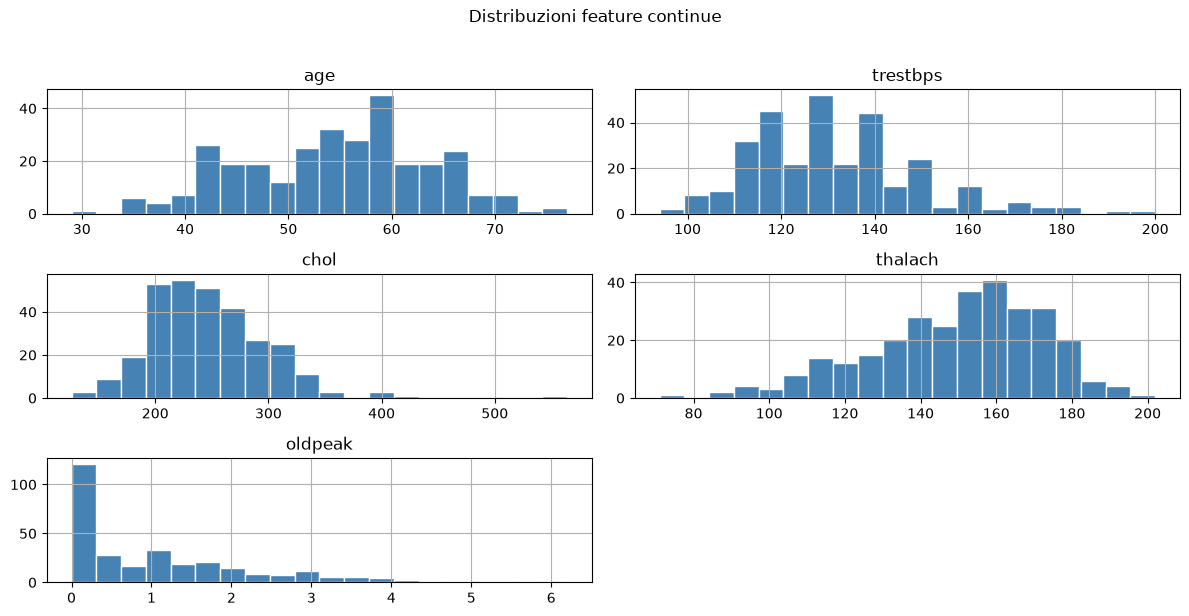

In [12]:
cont = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[cont].hist(figsize=(12, 6), bins=20, color="steelblue", edgecolor="white")
plt.suptitle("Distribuzioni feature continue", y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature categoriche vs target

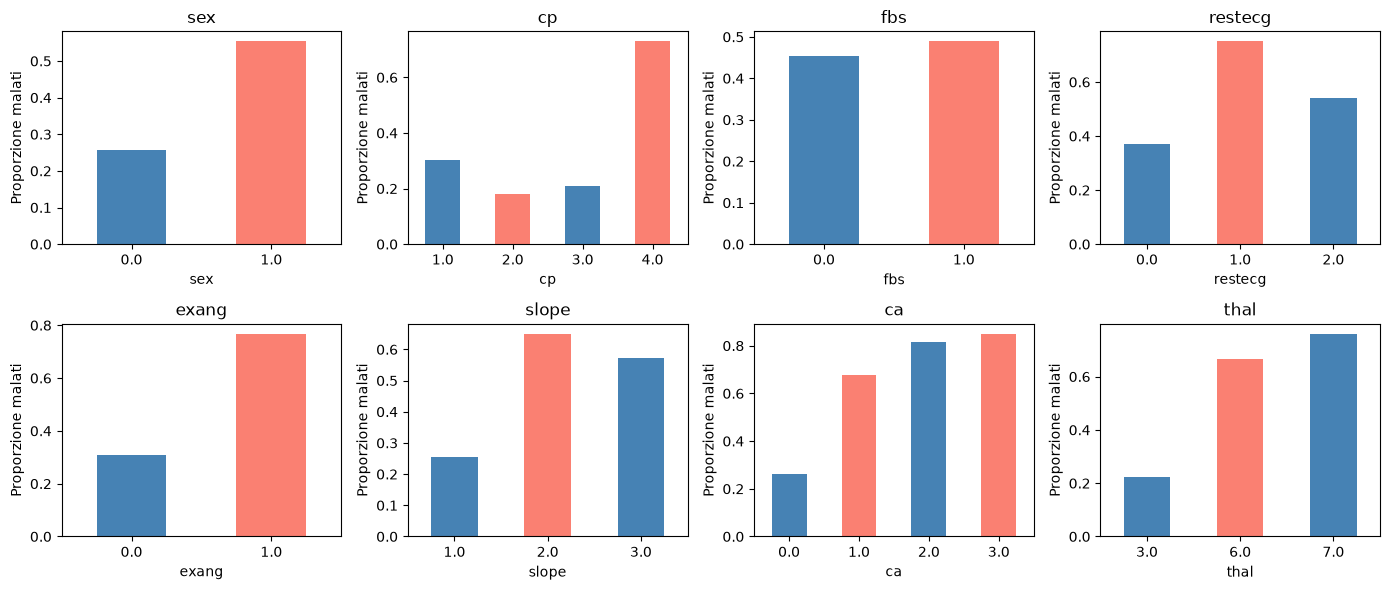

In [13]:
cat = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flatten(), cat):
    df.groupby(col)["target"].mean().plot.bar(ax=ax, color=["steelblue", "salmon"])
    ax.set_title(col)
    ax.set_ylabel("Proporzione malati")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 5. Correlazione con il target

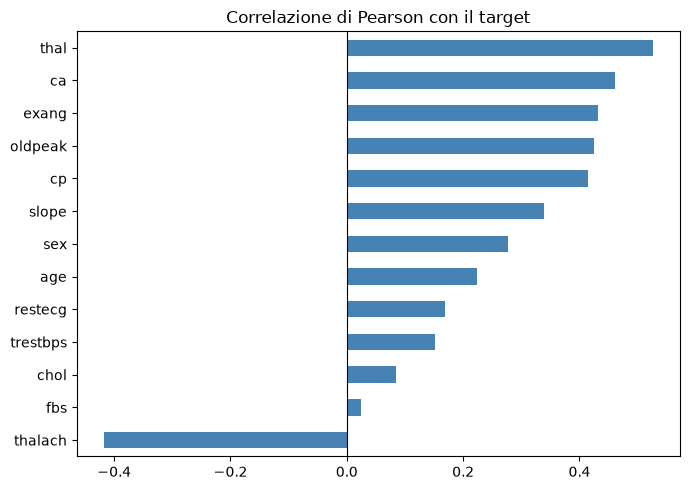

In [14]:
(df.corr(numeric_only=True)["target"]
   .drop("target")
   .sort_values()
   .plot.barh(figsize=(7, 5), color="steelblue"))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlazione di Pearson con il target")
plt.tight_layout()
plt.show()

## 6. Matrice di correlazione tra feature

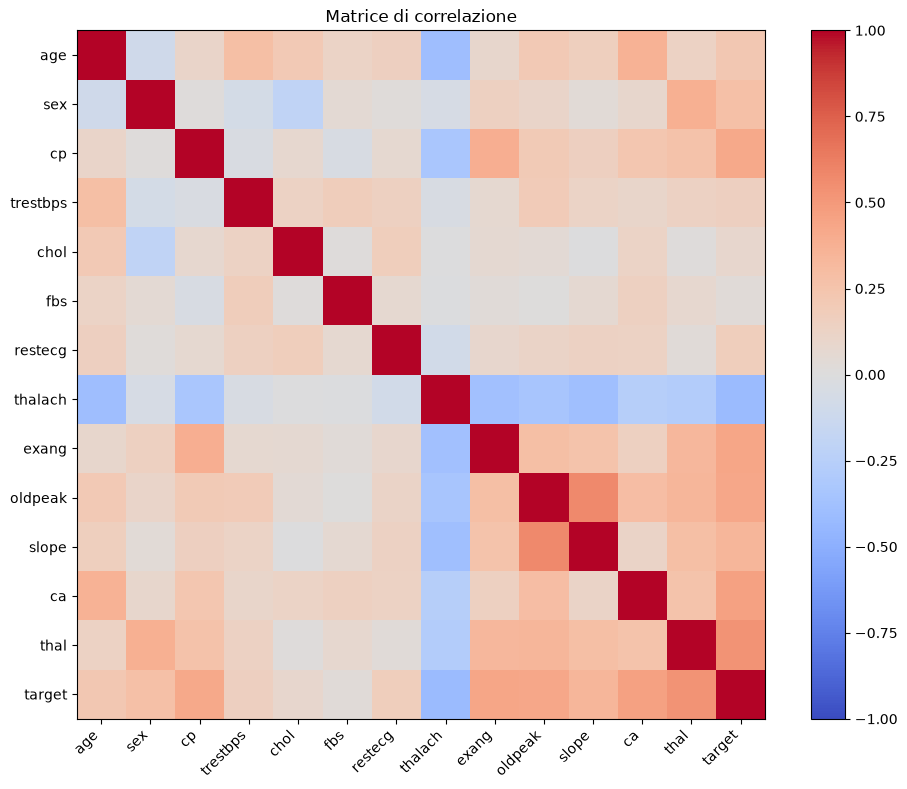

In [15]:
import matplotlib.cm as cm
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
plt.title("Matrice di correlazione")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'artifacts/oldpeak_distribuzione.png'

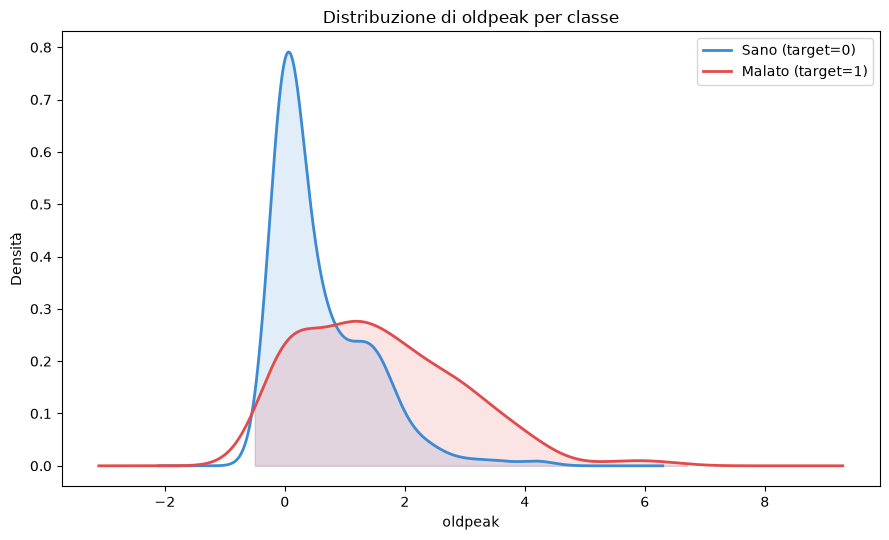

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

df = pd.read_csv(r"C:\Users\ELIA\Documents\Tesi\Script\Tesi-XAI\data\heart_disease_cleveland.csv")

FEATURE = 'oldpeak'   # <-- cambia qui per un'altra variabile continua

sani = df[df['target']==0][FEATURE]
malati = df[df['target']==1][FEATURE]

fig, ax = plt.subplots(figsize=(9,5.5))
sani.plot.kde(ax=ax, color='#3B8BD4', linewidth=2, label='Sano (target=0)')
malati.plot.kde(ax=ax, color='#E24B4A', linewidth=2, label='Malato (target=1)')

x_range = np.linspace(df[FEATURE].min()-0.5, df[FEATURE].max()+0.5, 300)
ax.fill_between(x_range, gaussian_kde(sani)(x_range), alpha=0.15, color='#3B8BD4')
ax.fill_between(x_range, gaussian_kde(malati)(x_range), alpha=0.15, color='#E24B4A')

ax.set_xlabel(FEATURE); ax.set_ylabel('Densità')
ax.set_title(f'Distribuzione di {FEATURE} per classe')
ax.legend()
plt.tight_layout()
plt.savefig(f'artifacts/{FEATURE}_distribuzione.png', dpi=140, bbox_inches='tight')